In [1]:
# The original file

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Open as a memory-mapped array (read-only)
df = np.load("C:/DCU_final_year_project/ItoQUVcorrected_CBJTML_hairlinefree_contnorm_630only.npy")

In [2]:
df.shape

df_original_v = df[3, :, :, :]
df_original_i = df[0, :, :, :]

# Description of what each dimension is y the number of elements present is given below
# 4 is Stokes I,Q,U,V
# 182 is the wavelength dimension 
# 2555 is the y direction which is along the slit of instrument)
# 900 is the scanning direction (x direction) temporal domain as instrument is scanned

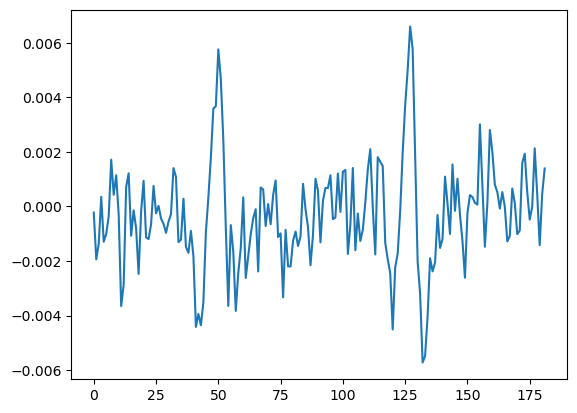

In [3]:
# plot profiles across wavelength spectra for:

# I, Q, U, V (first parameter of the array)
# and [y, x] (third and fourth parameters of the array respectively)

plt.plot(df[3, :, 200, 600])
plt.show()

# y= 1600, x= 100 for the V profile shows a case where the
# polarity of the profile's peak value is negative

# We need to clean data for:
# Doppler shift
# Polarity of the Stokes V profile
# Amplitude of the Stokes V profile

[ 47  86 123 146]


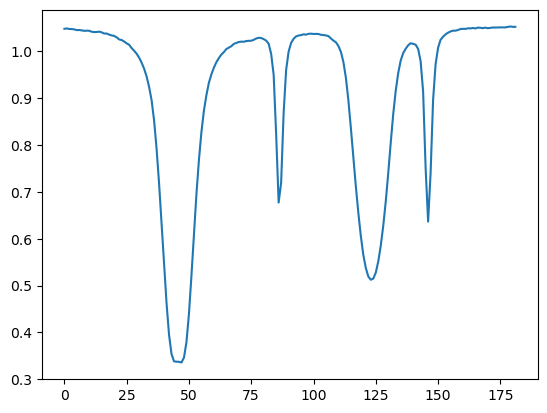

In [4]:
# In order to figure out the Doppler shift of the data, we
# use the absorption lines found in the Stokes I profile
# which contain two solar absorption lines (affected by Doppler shift)
# and two absorption lines from Earths atmosphere

sample_profile = df[0, :, 200, 660]
plt.plot(sample_profile)
plt.show

# find_peaks used to locate  absorption lines on Stokes I profile multiplied by -1
from scipy.signal import find_peaks
sample_profile.shape
sample_lines_tuple = find_peaks(-sample_profile, width = [0], prominence = [0.05])
#sample_lines_array = np.asarray(sample_lines_tuple)
# 'sample_lines, _' more legible for seeing printed output
# 'sample_lines' contains more data


sample_lines_array = sample_lines_tuple[0]

#Compare numbers found for absorption line to Stokes I plot

#print(sample_lines_tuple)
print(sample_lines_array)
#print(sample_lines_array)

# From left to right, the wider first and third lines are the
# solar absorption lines, and the narrower second and fourth lines
# are the absorption lines caused by the Earth's atmosphere

# Earth's atmospheric absorption lines are at wavelength numbers 86
# and 146 for any profile, but the solar absorption lines fluctuate
# due to Doppler shift


# There are some cases where the lines are split into two localised "peaks" in
# one absorption line, and the code in this current state will simply pick the peak with the
# lower minimum point.

In [5]:
# The width parameter of the find_peaks function can be used to separate the 
# solar absorption lines from Earth's absorption lines within the find_peaks function

# The prominence parameter makes sure no noise gets detected as a "peak"

solar_lines, _ = find_peaks(-sample_profile, width = [7], prominence = [0.1])
earth_lines, _ = find_peaks(-sample_profile, width = [0, 7], prominence = [0.1])

print(solar_lines)
print(earth_lines)

[ 47 123]
[ 86 146]


In [6]:
I_array = df[0]


# Define a function to find the 4 absorption lines' positions on each pixel

I_array.shape

wavelengths = np.linspace(0, 181, num = 182)

def find_line_wavelengths(I_profile, wavelengths):
    
    peaks, props = find_peaks(-I_profile, prominence = 0.02)
    if len(peaks) == 0:
        return np.array([np.nan] * 4)
    
    sort_index = np.argsort(props["prominences"])[::-1]
    main_peaks = peaks[sort_index[:4]]
    return np.sort(wavelengths[main_peaks])

In [ ]:
# Function that processes line positions for one row of the y axis at a time

n_lambda, n_y, n_x = I_array.shape
line_positions = np.full((4, n_y, n_x), np.nan, dtype = float)

for y in range(n_y):
    for x in range(n_x):
        spectrum = I_array[:, y, x]
        line_positions[:, y, x] = find_line_wavelengths(spectrum, wavelengths)
    print(f"Processed row {y+1}/{n_y}")

Processed row 1/2555
Processed row 2/2555
Processed row 3/2555
Processed row 4/2555
Processed row 5/2555
Processed row 6/2555
Processed row 7/2555
Processed row 8/2555
Processed row 9/2555
Processed row 10/2555
Processed row 11/2555
Processed row 12/2555
Processed row 13/2555
Processed row 14/2555
Processed row 15/2555
Processed row 16/2555
Processed row 17/2555
Processed row 18/2555
Processed row 19/2555
Processed row 20/2555
Processed row 21/2555
Processed row 22/2555
Processed row 23/2555
Processed row 24/2555
Processed row 25/2555
Processed row 26/2555
Processed row 27/2555
Processed row 28/2555
Processed row 29/2555
Processed row 30/2555
Processed row 31/2555
Processed row 32/2555
Processed row 33/2555
Processed row 34/2555
Processed row 35/2555
Processed row 36/2555
Processed row 37/2555
Processed row 38/2555
Processed row 39/2555
Processed row 40/2555
Processed row 41/2555
Processed row 42/2555
Processed row 43/2555
Processed row 44/2555
Processed row 45/2555
Processed row 46/25

In [ ]:
mean_lines = np.nanmean(line_positions, axis = (1, 2))
print("Average line wavelengths: ", mean_lines)
df_original_v.shape
# The first and third lines are from the solar atmosphere and are expected
# to be affected by Doppler shift

# The second and fourth lines are the lines due to Earth's atmosphere
# The 4th line appears to be always 146 but the second line sometimes had a different
# value than 86 (its average value is still 86.01 which is very close)

# Average for first line is 45.94 and for third line is 123.15

In [9]:
first_solar_line_average = np.mean(mean_lines[0:1])
second_solar_line_average = np.mean(mean_lines[2:3])

first_earth_line_average = np.mean(mean_lines[1:2])
second_earth_line_average = np.mean(mean_lines[3:])

print(f"First solar line average = {first_solar_line_average}")
print(f"Second solar line average = {second_solar_line_average}")

print(f"First Earth line average = {first_earth_line_average}")
print(f"Second Earth line average = {second_earth_line_average}")

# From these results

First solar line average = 45.94129028049576
Second solar line average = 123.14887801696021
First Earth line average = 86.01099934768428
Second Earth line average = 146.0


In [14]:
# Using np.roll to shift the lambda dimension to correct Doppler Shift 
# If np.roll is used without any other changes being made then the longest/shortest wavelengths
# get shifted to the other side, which is very bad
# Need to set values at points getting shifted to other side to NaN

# as an example of the function: np.roll(A,2) rolls a 1D array A by 2 places to the right

solar_line_corrected = 46 # first solar line is on average ~46
line_positions.shape

# line_positions is a 3D array of [4, 2555, 900] where 4 represents the two solar lines
# and two lines from Earth's atmopshere

# line_positions[0] calls the position of the first solar line of each pixel
delta_lambda = line_positions[0] - solar_line_corrected
# delta_lambda is then a [2555, 900] array showing the wavelength shift for each pixel

# n_lambda, n_y, n_x are defined as dimension sizes
# for the whole array earlier in the notebook
stokes_v_corrected_lambda = np.empty_like((n_lambda, n_y, n_x), dtype = df.dtype)

for y in range(n_y):
    for x in range(n_x):
        shift = delta_lambda[y, x]
        
        stokes_v_original = df[3, :, y, x]
        
        if np.isnan(shift):
            stokes_v_corrected_lambda[;, y, x] = stokes_v_original
            continue
        lambda_correction = wavelengths - shift



(2555, 900)

In [16]:
stokes_v_original = df[3, :, y, x]
stokes_v_original.shape

(182,)

In [47]:
# TRYING DIFFERENT METHOD IN THE CELL BELOW

# Get difference between average line value and value of each pixel to
# approximate Doppler shift

first_solar_average_integer = 46
delta_lambda = line_positions[0] - first_solar_average_integer

from scipy.interpolate import interp1d

#n_lambda = df.shape[1]
wavelengths = np.arange(n_lambda)

# Prepare array for corrected Stokes V wavelengths
stokes_v_corrected_lambda = np.empty_like((n_lambda, n_y, n_x), dtype = df.dtype)
    

for y in range(n_y):
    for x in range(n_x):
        shift = delta_lambda[y, x]
        
        stokes_v_original = df[3, :, y, x]
        stokes_v_copium = df[3, :, :, :]
        if np.isnan(shift):
            stokes_v_corrected_lambda[:, y, x] = stokes_v_original
            continue
            
        # Define shifted wavelength for given pixel
        
        lambda_shifted = wavelengths - shift
        
        # Interpolate the original spectrum onto the shifted grid
        f = interp1d(wavelengths, stokes_v_original, kind = 'linear',
                    bounds_error = False, fill_value = 'extrapolate')
        stokes_v_corrected_lambda = f(lambda_shifted)
        
    print(f"Processed y = {y+1}/{n_y}")

Processed y = 1/2555
Processed y = 2/2555
Processed y = 3/2555
Processed y = 4/2555
Processed y = 5/2555
Processed y = 6/2555
Processed y = 7/2555
Processed y = 8/2555
Processed y = 9/2555
Processed y = 10/2555
Processed y = 11/2555
Processed y = 12/2555
Processed y = 13/2555
Processed y = 14/2555
Processed y = 15/2555
Processed y = 16/2555
Processed y = 17/2555
Processed y = 18/2555
Processed y = 19/2555
Processed y = 20/2555
Processed y = 21/2555
Processed y = 22/2555
Processed y = 23/2555
Processed y = 24/2555
Processed y = 25/2555
Processed y = 26/2555
Processed y = 27/2555
Processed y = 28/2555
Processed y = 29/2555
Processed y = 30/2555
Processed y = 31/2555
Processed y = 32/2555
Processed y = 33/2555
Processed y = 34/2555
Processed y = 35/2555
Processed y = 36/2555
Processed y = 37/2555
Processed y = 38/2555
Processed y = 39/2555
Processed y = 40/2555
Processed y = 41/2555
Processed y = 42/2555
Processed y = 43/2555
Processed y = 44/2555
Processed y = 45/2555
Processed y = 46/25

Processed y = 362/2555
Processed y = 363/2555
Processed y = 364/2555
Processed y = 365/2555
Processed y = 366/2555
Processed y = 367/2555
Processed y = 368/2555
Processed y = 369/2555
Processed y = 370/2555
Processed y = 371/2555
Processed y = 372/2555
Processed y = 373/2555
Processed y = 374/2555
Processed y = 375/2555
Processed y = 376/2555
Processed y = 377/2555
Processed y = 378/2555
Processed y = 379/2555
Processed y = 380/2555
Processed y = 381/2555
Processed y = 382/2555
Processed y = 383/2555
Processed y = 384/2555
Processed y = 385/2555
Processed y = 386/2555
Processed y = 387/2555
Processed y = 388/2555
Processed y = 389/2555
Processed y = 390/2555
Processed y = 391/2555
Processed y = 392/2555
Processed y = 393/2555
Processed y = 394/2555
Processed y = 395/2555
Processed y = 396/2555
Processed y = 397/2555
Processed y = 398/2555
Processed y = 399/2555
Processed y = 400/2555
Processed y = 401/2555
Processed y = 402/2555
Processed y = 403/2555
Processed y = 404/2555
Processed y

Processed y = 720/2555
Processed y = 721/2555
Processed y = 722/2555
Processed y = 723/2555
Processed y = 724/2555
Processed y = 725/2555
Processed y = 726/2555
Processed y = 727/2555
Processed y = 728/2555
Processed y = 729/2555
Processed y = 730/2555
Processed y = 731/2555
Processed y = 732/2555
Processed y = 733/2555
Processed y = 734/2555
Processed y = 735/2555
Processed y = 736/2555
Processed y = 737/2555
Processed y = 738/2555
Processed y = 739/2555
Processed y = 740/2555
Processed y = 741/2555
Processed y = 742/2555
Processed y = 743/2555
Processed y = 744/2555
Processed y = 745/2555
Processed y = 746/2555
Processed y = 747/2555
Processed y = 748/2555
Processed y = 749/2555
Processed y = 750/2555
Processed y = 751/2555
Processed y = 752/2555
Processed y = 753/2555
Processed y = 754/2555
Processed y = 755/2555
Processed y = 756/2555
Processed y = 757/2555
Processed y = 758/2555
Processed y = 759/2555
Processed y = 760/2555
Processed y = 761/2555
Processed y = 762/2555
Processed y

Processed y = 1075/2555
Processed y = 1076/2555
Processed y = 1077/2555
Processed y = 1078/2555
Processed y = 1079/2555
Processed y = 1080/2555
Processed y = 1081/2555
Processed y = 1082/2555
Processed y = 1083/2555
Processed y = 1084/2555
Processed y = 1085/2555
Processed y = 1086/2555
Processed y = 1087/2555
Processed y = 1088/2555
Processed y = 1089/2555
Processed y = 1090/2555
Processed y = 1091/2555
Processed y = 1092/2555
Processed y = 1093/2555
Processed y = 1094/2555
Processed y = 1095/2555
Processed y = 1096/2555
Processed y = 1097/2555
Processed y = 1098/2555
Processed y = 1099/2555
Processed y = 1100/2555
Processed y = 1101/2555
Processed y = 1102/2555
Processed y = 1103/2555
Processed y = 1104/2555
Processed y = 1105/2555
Processed y = 1106/2555
Processed y = 1107/2555
Processed y = 1108/2555
Processed y = 1109/2555
Processed y = 1110/2555
Processed y = 1111/2555
Processed y = 1112/2555
Processed y = 1113/2555
Processed y = 1114/2555
Processed y = 1115/2555
Processed y = 11

Processed y = 1418/2555
Processed y = 1419/2555
Processed y = 1420/2555
Processed y = 1421/2555
Processed y = 1422/2555
Processed y = 1423/2555
Processed y = 1424/2555
Processed y = 1425/2555
Processed y = 1426/2555
Processed y = 1427/2555
Processed y = 1428/2555
Processed y = 1429/2555
Processed y = 1430/2555
Processed y = 1431/2555
Processed y = 1432/2555
Processed y = 1433/2555
Processed y = 1434/2555
Processed y = 1435/2555
Processed y = 1436/2555
Processed y = 1437/2555
Processed y = 1438/2555
Processed y = 1439/2555
Processed y = 1440/2555
Processed y = 1441/2555
Processed y = 1442/2555
Processed y = 1443/2555
Processed y = 1444/2555
Processed y = 1445/2555
Processed y = 1446/2555
Processed y = 1447/2555
Processed y = 1448/2555
Processed y = 1449/2555
Processed y = 1450/2555
Processed y = 1451/2555
Processed y = 1452/2555
Processed y = 1453/2555
Processed y = 1454/2555
Processed y = 1455/2555
Processed y = 1456/2555
Processed y = 1457/2555
Processed y = 1458/2555
Processed y = 14

Processed y = 1760/2555
Processed y = 1761/2555
Processed y = 1762/2555
Processed y = 1763/2555
Processed y = 1764/2555
Processed y = 1765/2555
Processed y = 1766/2555
Processed y = 1767/2555
Processed y = 1768/2555
Processed y = 1769/2555
Processed y = 1770/2555
Processed y = 1771/2555
Processed y = 1772/2555
Processed y = 1773/2555
Processed y = 1774/2555
Processed y = 1775/2555
Processed y = 1776/2555
Processed y = 1777/2555
Processed y = 1778/2555
Processed y = 1779/2555
Processed y = 1780/2555
Processed y = 1781/2555
Processed y = 1782/2555
Processed y = 1783/2555
Processed y = 1784/2555
Processed y = 1785/2555
Processed y = 1786/2555
Processed y = 1787/2555
Processed y = 1788/2555
Processed y = 1789/2555
Processed y = 1790/2555
Processed y = 1791/2555
Processed y = 1792/2555
Processed y = 1793/2555
Processed y = 1794/2555
Processed y = 1795/2555
Processed y = 1796/2555
Processed y = 1797/2555
Processed y = 1798/2555
Processed y = 1799/2555
Processed y = 1800/2555
Processed y = 18

Processed y = 2102/2555
Processed y = 2103/2555
Processed y = 2104/2555
Processed y = 2105/2555
Processed y = 2106/2555
Processed y = 2107/2555
Processed y = 2108/2555
Processed y = 2109/2555
Processed y = 2110/2555
Processed y = 2111/2555
Processed y = 2112/2555
Processed y = 2113/2555
Processed y = 2114/2555
Processed y = 2115/2555
Processed y = 2116/2555
Processed y = 2117/2555
Processed y = 2118/2555
Processed y = 2119/2555
Processed y = 2120/2555
Processed y = 2121/2555
Processed y = 2122/2555
Processed y = 2123/2555
Processed y = 2124/2555
Processed y = 2125/2555
Processed y = 2126/2555
Processed y = 2127/2555
Processed y = 2128/2555
Processed y = 2129/2555
Processed y = 2130/2555
Processed y = 2131/2555
Processed y = 2132/2555
Processed y = 2133/2555
Processed y = 2134/2555
Processed y = 2135/2555
Processed y = 2136/2555
Processed y = 2137/2555
Processed y = 2138/2555
Processed y = 2139/2555
Processed y = 2140/2555
Processed y = 2141/2555
Processed y = 2142/2555
Processed y = 21

Processed y = 2444/2555
Processed y = 2445/2555
Processed y = 2446/2555
Processed y = 2447/2555
Processed y = 2448/2555
Processed y = 2449/2555
Processed y = 2450/2555
Processed y = 2451/2555
Processed y = 2452/2555
Processed y = 2453/2555
Processed y = 2454/2555
Processed y = 2455/2555
Processed y = 2456/2555
Processed y = 2457/2555
Processed y = 2458/2555
Processed y = 2459/2555
Processed y = 2460/2555
Processed y = 2461/2555
Processed y = 2462/2555
Processed y = 2463/2555
Processed y = 2464/2555
Processed y = 2465/2555
Processed y = 2466/2555
Processed y = 2467/2555
Processed y = 2468/2555
Processed y = 2469/2555
Processed y = 2470/2555
Processed y = 2471/2555
Processed y = 2472/2555
Processed y = 2473/2555
Processed y = 2474/2555
Processed y = 2475/2555
Processed y = 2476/2555
Processed y = 2477/2555
Processed y = 2478/2555
Processed y = 2479/2555
Processed y = 2480/2555
Processed y = 2481/2555
Processed y = 2482/2555
Processed y = 2483/2555
Processed y = 2484/2555
Processed y = 24

In [50]:
y_test = 0
x_test = 0

stokes_v_corrected_lambda.shape

frick = stokes_v_corrected_lambda.append()

#ooga_booga = np.array(help_me)
#ooga_booga.shape
#spaghetti_code_array = ooga_booga[0, :]

#plt.plot(spaghetti_code_array, df_original_v[:, y_test, x_test])
#plt.plot(wavelengths, df_original_v[:, y_test, x_test] )
#plt.show()


(182,)

In [27]:
# Preparation for ndimage.shift
from scipy import ndimage

first_solar_average_integer = 46
delta_lambda = line_positions[0] - first_solar_average_integer
wavelengths = np.arange(n_lambda)

lambda_step = wavelengths[1] - wavelengths [0] #just an existence check for 'wavelengths'

shift_samples = delta_lambda / lambda_step

In [28]:
# ndimage.shift parameters

order = 3     # 3 = cubic interpolation for accuracy, 1 = linear interpolation for faster results
mode = 'nearest' # how edges are filled
cval = 0.0     # used when mode = 'constant'

chunk_size = 50   # number of y rows per chunk
stokes_v_original = df[3, :, :, :]

for y0 in range(0, n_y, chunk_size):
    y1 = min(y0 + chunk_size, n_y)
    # Load chunk of Stokes V into memory with shape (n_lambda, chunk_y, n_x)
    v_chunk = df[3, :, y0:y1, :] #memmap slice
    # Copy into RAM (so ndimage.shift doesn't attempt to write into same memmap buffer)
    v_chunk = np.array(v_chunk, dtype = float, copy = True)
    
    # corresponding shift samples chunk shape (chunk_y, n_x)
    shift_chunk = shift_samples[y0:y1, :]
    
    # Iterate over each pixel in the chunk
    for j in range(v_chunk.shape[1]): # j indexes y within chunk
        for i in range(n_x):          # i indexes x
            s = shift_chunk[j, i]
            v_profile = v_chunk[:, j, i]
            
            # if shift is nan, copy original
            if np.isnan(s):
                corrected = v_profile
            else: 
                 # ndimage.shift expects a sequence of shifts for each axis.
                # For a 1D array we pass [s] (positive s moves content to higher indices).
                # We want to *cancel* the Doppler shift: if the pixel is redshifted
                # (positive delta_lambda), we must shift the profile *back* by +shift_samples.
                # Here `s` is pixel_line - reference; we want to shift the profile by -s_samples
                # to align to reference. So use shift = -s.
                
                corrected = ndimage.shift(v_profile, shift = -s,
                                         order = order, mode = mode, cval = cval,
                                          prefilter = True)
            v_chunk[:, j, i] = corrected
        
        # Write corrected chunk back to memmap
        df[3, :, y0:y1, :] = v_chunk
        
        print(f"Processed rows y = {y0}..{y1 - 1}")



Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
P

Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
P

Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
P

Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
P

Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
P

Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
P

Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
P

Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
P

Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
Processed rows y = 0..2554
P

In [39]:
np.save("C:/DCU_final_year_project/ItoQUVcorrected_CBJTML_DopplerCorrected.npy", df)

# Doppler corrected file has been saved

#stokes_v_corrected_lambda.shape

#stokes_v_original = stokes_v_original[:, np.
stokes_v_original.shape

#v_chunk.shape
#corrected.shape
stokes_v_corrected_lambda.shape

(182,)

In [50]:
# Compare shifted to non-shifted
#original_wav_axis
y_test, x_test = 1221, 420

#v[] = stokes_v_corrected_lambda[]

plt.figure(figsize=(8,4))
#plt.plot(original_wav_axis, np.array(original_v := np.array(np.load('C:/DCU_final_year_project/ItoQUVcorrected_CBJTML_hairlinefree_contnorm_630only.npy', mmap_mode='r'))[3, :, y_test, x_test]), label='Original') 
# but you already had df memmap; if it's still loaded use:
original_v = df_original_v[:, y_test, x_test]  # if you saved a before-copy
#corrected_v = np.array([([df[3,:,:,:]],[stokes_v_corrected_lambda], [y_test], [x_test])])

plt.plot(wavelengths, original_v, label='Original')
plt.plot(wavelengths, corrected_v, linestyle='--', label='Doppler-corrected')
plt.legend()
plt.show()

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 3 dimensions. The detected shape was (1, 4, 1) + inhomogeneous part.

<Figure size 800x400 with 0 Axes>